# Customer Segmentation for Business Decision-Making
### H&M Case Study | Business Analytics, SQL (DuckDB), Power BI, Python

**Objective:** Evaluate whether a behavioral segmentation layer could improve customer targeting decisions compared with a legacy rule-based RFM framework. I focused on three business questions: where premium value is overstated, where omnichannel growth is most scalable, and where retention effort should be prioritized.

This notebook is structured as a business analytics workflow. I start with a transparent rule-based baseline, use K-Means as a behavioral challenger, compare both systems directly, and then translate the results into decision-oriented business insights for Power BI.

## Notebook Roadmap

1. Environment setup and data ingestion  
2. Transaction window and price normalization
3. Data quality review and cleaning    
4. Customer-level RFM construction  
5. Legacy segmentation baseline  
6. K-Means as a behavioral challenger  
7. Legacy vs. K-Means comparison  
8. SQL-based business insights  
9. Export for Power BI

## 1. Setup and Data Ingestion



In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import duckdb

In [2]:
project_path = Path.cwd().parent

data_path = project_path / "data"
export_path = project_path / "exports"

transactions_path = data_path / "transactions_train.csv"
customers_path = data_path / "customers.csv"
articles_path = data_path / "articles.csv"

# pyarrow for performance
df_transactions = pd.read_csv(transactions_path, engine="pyarrow", dtype_backend="pyarrow")
df_customers = pd.read_csv(customers_path, engine="pyarrow", dtype_backend="pyarrow")
df_articles = pd.read_csv(articles_path, engine="pyarrow", dtype_backend="pyarrow")

## 2. Transaction Window and Price Normalization

**Why this matters**  
I restricted the analysis to the latest 12 months so that customer behavior reflects a realistic decision horizon for retention and targeting. Using the full historical dataset would overstate the relevance of older purchases and dilute current customer value signals.

**Why price normalization is required**  
The raw transaction file stores price in a scaled format. I restored a usable monetary unit before calculating spend-based metrics so that all downstream customer value measures are interpretable.

In [3]:
print('Transactions before time filter:',df_transactions.shape)

start_date = pd.Timestamp('2019-09-01')
df_transactions = df_transactions[df_transactions['t_dat'] >= start_date]

print('Transactions after time filter:',df_transactions.shape)

Transactions before time filter: (31788324, 5)
Transactions after time filter: (15670430, 5)


In [4]:
print('Price distribution before rescaling:')
print(df_transactions['price'].describe())

df_transactions['price'] = (df_transactions['price'] * 1000).round(2)

print('\nPrice distribution after rescaling:')
print(df_transactions['price'].describe())

Price distribution before rescaling:
count    15670430.0
mean       0.028435
std        0.019281
min        0.000017
25%        0.016932
50%        0.025407
75%        0.033881
max         0.50678
Name: price, dtype: double[pyarrow]

Price distribution after rescaling:
count    15670430.0
mean      28.434715
std       19.281439
min            0.02
25%           16.93
50%           25.41
75%           33.88
max          506.78
Name: price, dtype: double[pyarrow]


## 3. Data Quality Review and Cleaning

I validate schema consistency, remove duplicate keys, standardize categorical fields, and keep only the columns required for segmentation and reporting.

In [5]:
# Data quality adjustments applied

# Missing values
df_customers['FN'] = df_customers['FN'].fillna(0)
df_customers['Active'] = df_customers['Active'].fillna(0)
df_customers['age'] = df_customers['age'].fillna(df_customers['age'].median())
df_customers['club_member_status'] = df_customers['club_member_status'].fillna('unknown')
df_customers['fashion_news_frequency'] = df_customers['fashion_news_frequency'].fillna('unknown')

# Duplicates id
df_customers = df_customers.drop_duplicates(subset=['customer_id'])
df_articles = df_articles.drop_duplicates(subset=['article_id'])

# Validation
print('Duplicate article_id rows:', df_articles.duplicated("article_id").sum())
print('Duplicate customer_id rows:', df_customers.duplicated("customer_id").sum())
print('Remaining nulls in customers:', df_customers.isnull().sum().sum())

Duplicate article_id rows: 0
Duplicate customer_id rows: 0
Remaining nulls in customers: 0


### Column Selection

In [6]:
df_customers = df_customers.drop(columns='postal_code')

df_articles = df_articles[['article_id', 'prod_name', 'product_type_name', 'product_group_name', 'colour_group_name', 'index_group_name', 'garment_group_name']]

### Standardizing Article Attributes

In [7]:
article_attributes = [
    'product_type_name', 
    'product_group_name', 
    'colour_group_name', 
    'index_group_name', 
    'garment_group_name'
]
# Standardize categorical fields to ensure consistent grouping and reporting
print('Distinct values after normalization:')
for col in article_attributes:
    df_articles[col] = df_articles[col].str.strip().str.lower()
    print(col,df_articles[col].nunique())


Distinct values after normalization:
product_type_name 130
product_group_name 19
colour_group_name 50
index_group_name 5
garment_group_name 21


### Merging data into one table

In [8]:
print('Transactions shape before merges:', df_transactions.shape)

df_merged = pd.merge(df_transactions, df_customers, how= 'left', on= 'customer_id')
df_merged = pd.merge(df_merged, df_articles, how= 'left', on= 'article_id')

print('Merged shape:', df_merged.shape)

Transactions shape before merges: (15670430, 5)
Merged shape: (15670430, 16)


In [9]:
print('Merges validation')
print('Rows without customer data:', df_merged['age'].isnull().sum())
print('Rows without article data:', df_merged['prod_name'].isnull().sum())

Merges validation
Rows without customer data: 0
Rows without article data: 0


## 4. Customer-Level RFM Construction

The RFM framework converts raw transaction logs into a customer-level view of behavior. I use RFM as the baseline because it is familiar, interpretable, and common in business environments.

In [10]:
analysis_last_date = df_merged['t_dat'].max() + pd.Timedelta(days=1)

In [11]:
df_rfm = df_merged.groupby('customer_id').agg(
    last_purchase_date = ('t_dat', 'max'),
    frequency = ('article_id' , 'count'),
    monetary = ('price' , 'sum')
).reset_index()

In [12]:
df_rfm['recency'] = (analysis_last_date - df_rfm['last_purchase_date']).dt.days
df_rfm = df_rfm.drop(columns='last_purchase_date')
df_rfm[["recency", "frequency", "monetary"]].describe().round(2)

,recency,frequency,monetary
count,1012760.0,1012760.0,1012760.0
mean,122.18,15.47,439.97
std,107.18,22.88,713.33
min,1.0,1.0,0.76
25%,32.0,3.0,84.68
50%,88.0,8.0,206.59
75%,195.0,19.0,503.11
max,388.0,1067.0,35141.42


In [13]:
fm_scores = [1, 2, 3, 4, 5]
r_scores = [5, 4, 3, 2, 1]

In [14]:
df_rfm['R'] = pd.qcut(df_rfm['recency'], q=5, labels=r_scores).astype('int')
df_rfm['F'] = pd.qcut(df_rfm['frequency'], q=5, labels=fm_scores).astype('int')
df_rfm['M'] = pd.qcut(df_rfm['monetary'], q=5, labels=fm_scores).astype('int')

df_rfm.head(2)

,customer_id,frequency,monetary,recency,R,F,M
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,13,393.18,18,5,4,4
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,35,887.54,77,3,5,5


## 5. Legacy Segmentation Baseline

I recreate the historical rules-based segmentation before introducing the challenger model. Specifically, this approach condenses the traditional 11 RFM segments into 5 highly actionable groups.

In [15]:
rule_conditions = [
    # 1. VIP
    (df_rfm['R'] >= 4) & (df_rfm['F'] >= 4) & (df_rfm['M'] >= 4),
    
    # 2. churning VIP
    (df_rfm['R'] <= 2) & (df_rfm['F'] >= 3) & (df_rfm['M'] >= 4),
    
    # 3. regular
    (df_rfm['R'] >= 3) & (df_rfm['F'] >= 2),

    # 4. new customer
    (df_rfm['R'] >= 4) & (df_rfm['F'] <= 2),
]

rule_labels = [
    'vip',
    'churning vip',
    'regular',
    'new customer'
]

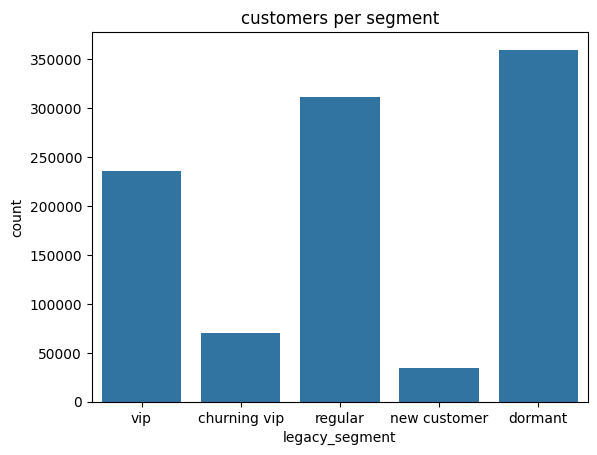

In [16]:
df_rfm['legacy_segment'] = np.select(rule_conditions, rule_labels, default='dormant')

segment_order = ['vip', 'churning vip', 'regular', 'new customer', 'dormant']
sns.barplot(df_rfm['legacy_segment'].value_counts(), order=segment_order)
plt.title('customers per segment')
plt.show()

## 6. Behavioral Segmentation Challenger (K-Means)

**Why add a behavioral challenger**  
The goal is not to directly replace business logic with a Machine Learning model. The goal is to test whether static segmentation rules are broad enough to misclassify customer value or retention priority.

Because K-Means is distance-based, I standardize the RFM inputs and cap extreme values so a small number of outliers do not dominate the final cluster formation.

In [17]:
df_kmeans = df_rfm[[ 'recency' , 'frequency' , 'monetary']].copy()
# checking percentiles for outliers
percen = [0.98 , 0.985, 0.99, 0.995]

df_kmeans.describe(percentiles=percen)

,recency,frequency,monetary
count,1012760.0,1012760.0,1012760.0
mean,122.176413,15.472995,439.970199
std,107.17534,22.879447,713.327949
min,1.0,1.0,0.76
50%,88.0,8.0,206.59
98%,364.0,83.0,2528.2764
98.5%,371.0,93.0,2862.3369
99%,377.0,108.0,3374.3353
99.5%,382.0,138.0,4353.6523
max,388.0,1067.0,35141.42


In [18]:
frequency_cap = df_kmeans['frequency'].quantile(0.99)
monetary_cap = df_kmeans['monetary'].quantile(0.99)

df_kmeans['frequency'] = df_kmeans['frequency'].clip(upper=frequency_cap)
df_kmeans['monetary'] = df_kmeans['monetary'].clip(upper=monetary_cap)

In [19]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_kmeans)
df_scaled = pd.DataFrame(scaled_data, columns= ['recency' ,	'frequency' ,	'monetary'])

In [20]:
# Use a representative sample for cluster validation metrics to keep computation manageable.
df_sample = df_scaled.sample(frac=0.1, random_state=42)


k_values = range(2, 11)
inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_kmeans = kmeans.fit_predict(df_sample)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_sample, labels_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(df_sample, labels_kmeans))

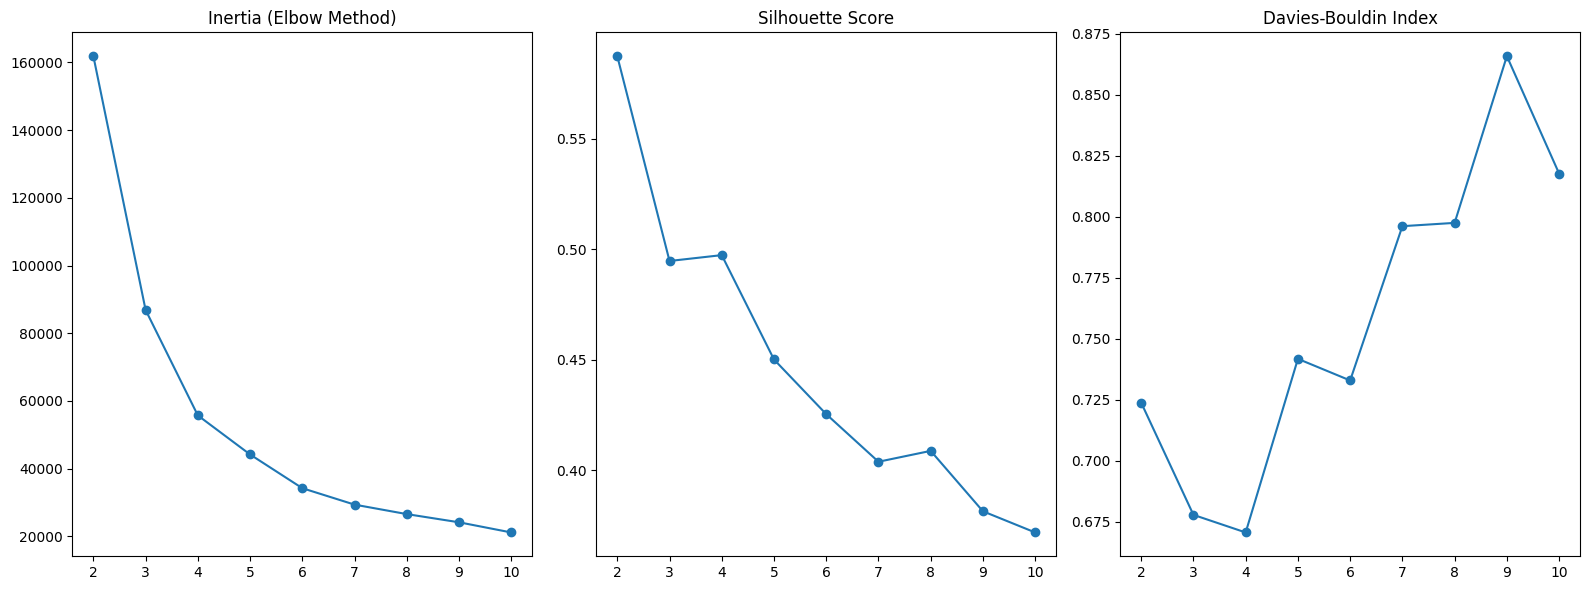

In [21]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker='o')
plt.title('Inertia (Elbow Method)')

plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker='o')
plt.title('Davies-Bouldin Index')

plt.tight_layout()

I selected **four clusters** because this solution aligned with the validation metrics and produced a clear, operationally usable segment structure for business decisions.

In [22]:
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_rfm['kmeans_cluster'] = kmeans_model.fit_predict(df_scaled)

In [23]:
df_cluster_segment = df_rfm.groupby('kmeans_cluster').agg(
    recency_mean = ('recency', 'mean'),
    frequency_mean = ('frequency', 'mean'),
    monetary_mean = ('monetary', 'mean'),
    total_customers = ('kmeans_cluster', 'count')
).round(2)

df_cluster_segment

,recency_mean,frequency_mean,monetary_mean,total_customers
kmeans_cluster,,,,
0,270.57,4.74,140.21,287543
1,28.19,94.92,2945.3,42866
2,71.59,8.65,226.45,516602
3,46.72,34.81,977.55,165749


K-Means cluster IDs are arbitrary, so I assign business-facing names after reviewing each cluster profile.

In [24]:
cluster_names = {
    1: 'vip',
    3: 'loyal',
    2: 'regular',
    0: 'dormant'
}
df_rfm['kmeans_segment'] = df_rfm['kmeans_cluster'].map(cluster_names)

## 7. Legacy Baseline vs. Behavioral Segmentation

This section compares the rule-based segmentation with the learned clusters to quantify where the historical logic overstates customer value or misclassifies inactive users.

In [25]:
segment_crosstab = pd.crosstab(df_rfm['legacy_segment'], df_rfm['kmeans_segment'])

rfm_order = ['vip', 'churning vip', 'regular', 'new customer', 'dormant']
kmeans_order = [ 'dormant' ,  'regular'  , 'loyal', 'vip']

segment_crosstab = segment_crosstab.loc[rfm_order , kmeans_order]

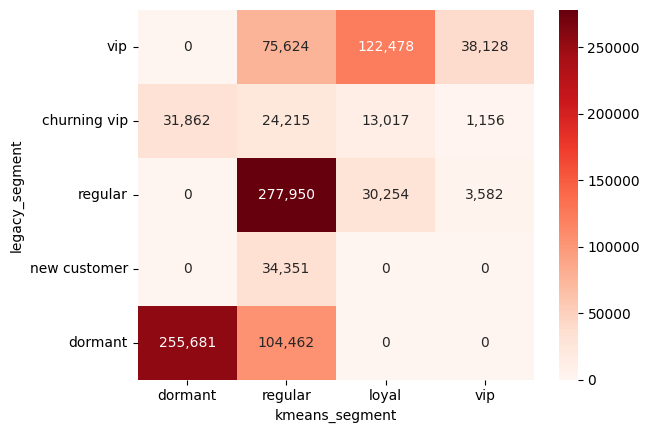

In [26]:
sns.heatmap(segment_crosstab, annot=True, fmt=',.0f', cmap='Reds')
plt.show()

### Executive takeaway: the legacy rule set overstates customer value

- The rules-based model is materially more optimistic than the behavioral segmentation.
- A large share of legacy VIP customers are reclassified into lower-priority groups.
- Many customers treated as at-risk premium users under the legacy model already behave more like dormant customers.

**Business implication:** K-Means gives the marketing team a more realistic view of customer value and helps reallocate budget toward segments with higher conversion and retention potential.

## 8. SQL-Based Business Insights

**From segmentation to decision support**  
Once both segmentations were defined, I used DuckDB SQL to answer business questions that a marketing or commercial team could act on directly: where retention effort may be wasted, where omnichannel development is most valuable, and where inactivity risk is concentrated among high-value customers.

### 8.1 Audit on Misclassified Retention Target

**Business question:** Are we wasting marketing budget on the Churning VIPs labeled as 'Dormant' by K-Means?

In [27]:
query_1 = '''
SELECT 
    legacy_segment,
    kmeans_segment,
    COUNT(customer_id) AS total_customers,
    ROUND(AVG(recency), 0) AS avg_days_since_purchase,
    ROUND(AVG(monetary), 0) AS avg_annual_spend
FROM df_rfm
WHERE legacy_segment = 'churning vip' AND kmeans_segment = 'dormant'
GROUP BY legacy_segment, kmeans_segment;
'''
df_audit_insight = duckdb.query(query_1).df()
df_audit_insight

,legacy_segment,kmeans_segment,total_customers,avg_days_since_purchase,avg_annual_spend
0,churning vip,dormant,31862,259.0,469.0


### 8.2 Omnichannel Spend by Segment

**Business question:** Do customers who buy through more than one channel generate a higher average ticket than single-channel shoppers, and how large is the spend gap by cluster?

In [28]:
query_2 = '''
WITH ChannelCount AS (
    SELECT 
        customer_id, 
        COUNT(DISTINCT sales_channel_id) AS channels_used
    FROM df_merged
    GROUP BY customer_id
)
SELECT 
    r.kmeans_segment,
    c.channels_used,
    COUNT(r.customer_id) AS total_customers,
    ROUND(AVG(r.monetary), 2) AS avg_annual_spend
FROM df_rfm r
JOIN ChannelCount c ON r.customer_id = c.customer_id
GROUP BY r.kmeans_segment, c.channels_used
ORDER BY r.kmeans_segment;
'''
df_omnichannel_insight = duckdb.query(query_2).df()
df_omnichannel_insight

,kmeans_segment,channels_used,total_customers,avg_annual_spend
0,dormant,1,258491,126.62
1,dormant,2,29052,261.13
2,loyal,2,113157,973.69
3,loyal,1,52592,985.86
4,regular,1,357264,186.82
5,regular,2,159338,315.32
6,vip,1,11142,3017.68
7,vip,2,31724,2919.88


### 8.3 Retention Risk

**Business question:** At what recency threshold does a customer fall into the top decile of inactivity for each cluster, and how much historical revenue sits beyond that warning line?

In [29]:
query_3 = '''
WITH PercentileLimits AS (
    SELECT 
        kmeans_segment, 
        QUANTILE_CONT(recency, 0.90) AS p90_days
    FROM df_rfm
    GROUP BY kmeans_segment
)
SELECT 
    r.kmeans_segment,
    ROUND(l.p90_days) AS p90_warning_day,
    COUNT(r.customer_id) AS customers_at_risk,
    ROUND(SUM(r.monetary), 2) AS historical_revenue
FROM df_rfm r
JOIN PercentileLimits l ON r.kmeans_segment = l.kmeans_segment
WHERE r.recency > l.p90_days
GROUP BY r.kmeans_segment, l.p90_days
ORDER BY historical_revenue DESC;
'''
df_risk_insight = duckdb.query(query_3).df()
df_risk_insight

,kmeans_segment,p90_warning_day,customers_at_risk,historical_revenue
0,loyal,106.0,16418,16664525.43
1,vip,68.0,4246,10795820.75
2,regular,144.0,51278,10479417.62
3,dormant,358.0,28017,3284273.39


## 9. Export for Power BI

In [30]:
df_rfm_powerbi = df_rfm[['customer_id', 'frequency', 'monetary', 'recency', 'legacy_segment', 'kmeans_segment']]

In [31]:
df_rfm_powerbi.to_parquet(export_path / 'df_rfm.parquet', index= False)
df_audit_insight.to_parquet(export_path / 'audit_insight.parquet' , index=False)
df_omnichannel_insight.to_parquet(export_path / 'omnichannel_insight.parquet' , index=False)
df_risk_insight.to_parquet(export_path / 'risk_insight.parquet' , index=False)

## Final Conclusion

This analysis shows that a familiar rule-based RFM framework can be improved by adding a behavioral challenger layer to audit customer prioritization.

The main business takeaway is not that a more advanced model is always better. It is that segmentation should support better decisions. In this case, the behavioral view helped identify where premium value was being overstated, where omnichannel growth was most scalable, and where retention effort should be prioritized based on value at risk.